# Deep Neural Network in Keras

In this notebook, we improve on our [intermediate neural net](https://github.com/the-deep-learners/deep-learning-illustrated/blob/master/notebooks/intermediate_net_in_keras.ipynb) by applying the theory we've covered since.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/the-deep-learners/deep-learning-illustrated/blob/master/notebooks/deep_net_in_keras.ipynb)

In [6]:
# import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

In [22]:
(X_train, y_train), (X_valid, y_valid) = mnist.load_data()
X_train = X_train.reshape(60000, 784).astype('float32')/255
X_valid = X_valid.reshape(10000, 784).astype('float32')/255
y_train = to_categorical(y_train, 10)
y_valid = to_categorical(y_valid, 10)

In [26]:
!rm -rf logs/deep-net
from tensorflow.keras.callbacks import TensorBoard
tensorboard = TensorBoard('logs/deep-net', histogram_freq=1)

model = Sequential([Input(shape=(784,)),
                    Dense(64, activation='relu'),
                    BatchNormalization(),

                    Dense(64, activation='relu'),
                    BatchNormalization(),

                    Dense(64, activation='relu'),
                    BatchNormalization(),
                    Dropout(0.2),

                    Dense(10, activation='softmax')]
)
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
)
# model.summary()
history = model.fit(X_train, y_train,
                    batch_size=128,
                    epochs=20,
                    verbose=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[tensorboard]
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8838 - loss: 0.3912 - val_accuracy: 0.9486 - val_loss: 0.1689
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9529 - loss: 0.1538 - val_accuracy: 0.9585 - val_loss: 0.1325
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9655 - loss: 0.1153 - val_accuracy: 0.9700 - val_loss: 0.0984
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9704 - loss: 0.0957 - val_accuracy: 0.9677 - val_loss: 0.1028
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9758 - loss: 0.0789 - val_accuracy: 0.9706 - val_loss: 0.1018
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9783 - loss: 0.0707 - val_accuracy: 0.9716 - val_loss: 0.0951
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9809 - loss: 0.0618 - val_accuracy: 0.9666 - val_loss: 0.1032
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9821 - loss: 0.0553 - val_accuracy: 0.

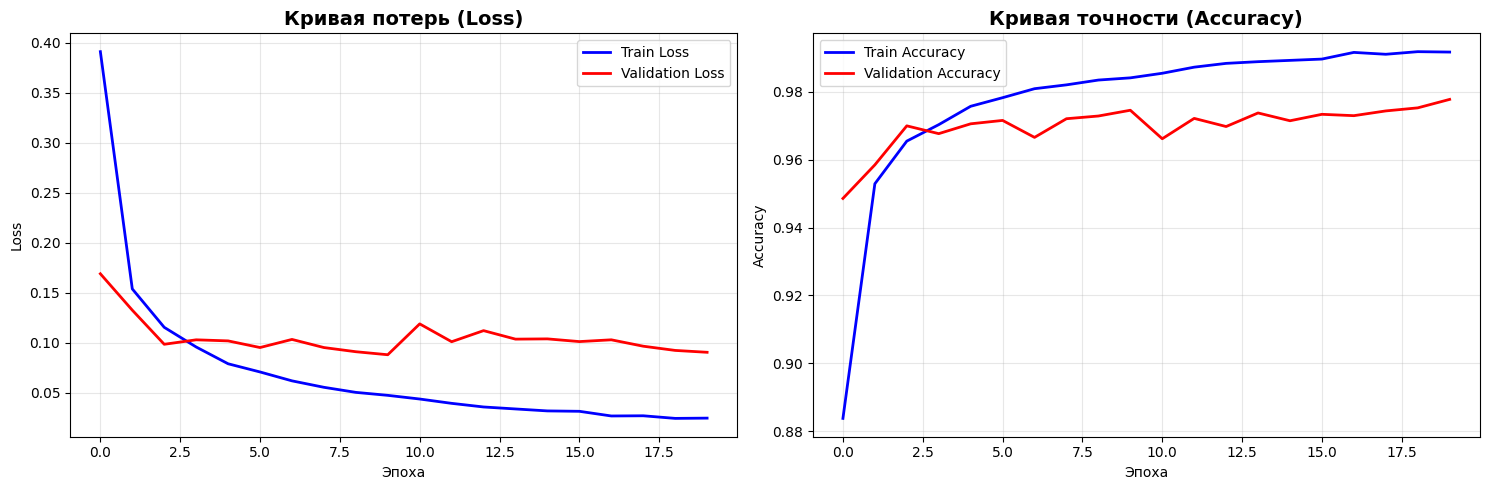


Лучшие результаты на эпохе 10:
  Train Loss: 0.0879
  Val Loss: 0.0879
  Train Accuracy: 0.9778
  Val Accuracy: 0.9778


In [27]:
import matplotlib.pyplot as plt

# Создаем графики в две колонки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Кривая потерь (loss)
ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
ax1.set_title('Кривая потерь (Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Кривая точности (accuracy)
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
ax2.set_title('Кривая точности (Accuracy)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительно: выводим лучшие результаты
best_epoch = history.history['val_loss'].index(min(history.history['val_loss'])) + 1
print(f"\nЛучшие результаты на эпохе {best_epoch}:")
print(f"  Train Loss: {min(history.history['val_loss']):.4f}")
print(f"  Val Loss: {min(history.history['val_loss']):.4f}")
print(f"  Train Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Val Accuracy: {max(history.history['val_accuracy']):.4f}")

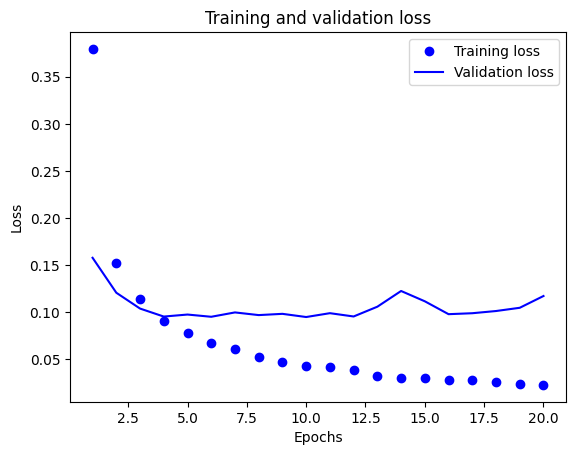

In [12]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
